# EfficientNet-B0 1D with 5-Fold Cross Validation

A 1D variant of EfficientNet-B0 adapted for time-series data (melting curves)


In [1]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, Dataset, SubsetRandomSampler
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import confusion_matrix, classification_report
from pathlib import Path
import json
from tqdm import tqdm
import warnings
warnings.filterwarnings('ignore')

# set random seeds for reproducibility
RANDOM_STATE = 8
torch.manual_seed(RANDOM_STATE)
np.random.seed(RANDOM_STATE)

# check what device we're using
if torch.cuda.is_available():
    DEVICE = torch.device('cuda')
    print(f"Using device: CUDA")
elif torch.backends.mps.is_available():
    DEVICE = torch.device('mps')
    print(f"Using device: MPS (Apple Silicon)")
else:
    DEVICE = torch.device('cpu')
    print(f"Using device: CPU")

print(f"PyTorch version: {torch.__version__}")

Using device: CUDA
PyTorch version: 2.9.0+cu130


## Configuration

Hyperparameters for 1D EfficientNet training

In [2]:
# paths and basic setup
DATA_FILE = Path('../../data/shark_dataset.csv')
N_FOLDS = 5

# training hyperparameters
BATCH_SIZE = 16
EPOCHS = 150
LEARNING_RATE = 0.001
WEIGHT_DECAY = 0.01
PATIENCE = 25

# focal loss parameters
FOCAL_ALPHA = 1.0
FOCAL_GAMMA = 2.0

# data augmentation
NOISE_STD = 0.01
SCALE_RANGE = 0.05  # +/- 5%
SHIFT_RANGE = 5  # time steps

## Data Loading

Load time-series data from CSV

In [3]:
# load data
df = pd.read_csv(DATA_FILE)
print(f"Dataset shape: {df.shape}")
print(f"Species: {df['Species'].nunique()} unique")
print(f"Columns: {df.columns[0]} (species), then {df.shape[1] - 1} time points")
print(f"\nFirst few species: {df['Species'].unique()[:5]}")

# extract features and labels
species = df['Species'].values
X = df.iloc[:, 1:].values.astype(np.float32)

# map species to indices
unique_species = sorted(np.unique(species))
species_to_idx = {s: i for i, s in enumerate(unique_species)}
y = np.array([species_to_idx[s] for s in species])
num_classes = len(unique_species)

print(f"\nData shape: {X.shape}")
print(f"Labels shape: {y.shape}")
print(f"Number of classes: {num_classes}")

Dataset shape: (651, 3476)
Species: 57 unique
Columns: Species (species), then 3475 time points

First few species: ['Arabian smooth-hound' 'Atlantic Sharpnose shark' 'Blackchin guitarfish'
 'Blacknose shark' 'Blackspotted smooth-hound']

Data shape: (651, 3475)
Labels shape: (651,)
Number of classes: 57


## Dataset Class

Custom PyTorch dataset with augmentation

In [4]:
class TimeSeriesDataset(Dataset):
    def __init__(self, X, y, normalize=True, augment=False):
        self.X = X
        self.y = y
        self.augment = augment
        
        # normalize
        if normalize:
            self.mean = X.mean(axis=0, keepdims=True)
            self.std = X.std(axis=0, keepdims=True) + 1e-8
            self.X = (X - self.mean) / self.std
        else:
            self.mean = 0
            self.std = 1
    
    def __len__(self):
        return len(self.X)
    
    def __getitem__(self, idx):
        x = self.X[idx].copy()
        y = self.y[idx]
        
        # augmentation (only on training)
        if self.augment:
            # add noise
            x = x + np.random.normal(0, NOISE_STD, x.shape)
            
            # random scaling (+/- 5%)
            scale = 1.0 + np.random.uniform(-SCALE_RANGE, SCALE_RANGE)
            x = x * scale
            
            # time-axis shift
            shift = np.random.randint(-SHIFT_RANGE, SHIFT_RANGE + 1)
            if shift > 0:
                x = np.concatenate([np.zeros(shift), x[:-shift]])
            elif shift < 0:
                x = np.concatenate([x[-shift:], np.zeros(-shift)])
        
        # convert to tensor
        x = torch.from_numpy(x).float()
        y = torch.tensor(y, dtype=torch.long)
        
        # add channel dimension (1, sequence_length)
        x = x.unsqueeze(0)
        
        return x, y

# test dataset
test_dataset = TimeSeriesDataset(X, y, normalize=True, augment=False)
x_sample, y_sample = test_dataset[0]
print(f"Sample shape: {x_sample.shape} (channels, time_steps)")

Sample shape: torch.Size([1, 3475]) (channels, time_steps)


## EfficientNet-B0 1D Architecture

A 1D variant adapted from EfficientNet-B0 with:
- Depthwise separable convolutions for efficiency
- Mobile inverted bottleneck blocks
- Squeeze-and-excitation modules

In [5]:
class Swish(nn.Module):
    """Swish activation function"""
    def forward(self, x):
        return x * torch.sigmoid(x)

class SEBlock1D(nn.Module):
    """Squeeze-and-Excitation block for 1D"""
    def __init__(self, channels, reduction=16):
        super().__init__()
        self.avg_pool = nn.AdaptiveAvgPool1d(1)
        reduced_channels = max(1, channels // reduction)
        self.fc1 = nn.Linear(channels, reduced_channels)
        self.fc2 = nn.Linear(reduced_channels, channels)
        self.activation = Swish()
    
    def forward(self, x):
        batch_size, channels, _ = x.size()
        # squeeze
        squeeze = self.avg_pool(x).view(batch_size, channels)
        # excitation
        excitation = self.fc1(squeeze)
        excitation = self.activation(excitation)
        excitation = self.fc2(excitation)
        excitation = torch.sigmoid(excitation)
        # scale
        return x * excitation.view(batch_size, channels, 1)

class MBConvBlock1D(nn.Module):
    """Mobile Inverted Bottleneck block for 1D"""
    def __init__(self, in_channels, out_channels, kernel_size, stride, expansion_factor, se_ratio=0.25):
        super().__init__()
        self.stride = stride
        self.in_channels = in_channels
        self.out_channels = out_channels
        expanded_channels = int(in_channels * expansion_factor)

        self.activation = Swish()

        # expansion phase
        self.expand_conv = None
        self.expand_bn = None
        if expansion_factor != 1:
            self.expand_conv = nn.Conv1d(in_channels, expanded_channels, kernel_size=1, stride=1, padding=0, bias=False)
            self.expand_bn = nn.BatchNorm1d(expanded_channels)

        # depthwise phase
        self.dw_conv = nn.Conv1d(expanded_channels, expanded_channels, kernel_size=kernel_size,
                                   stride=stride, padding=kernel_size//2, groups=expanded_channels, bias=False)
        self.dw_bn = nn.BatchNorm1d(expanded_channels)

        # squeeze-and-excitation
        self.se = SEBlock1D(expanded_channels, reduction=16)

        # projection phase
        self.project_conv = nn.Conv1d(expanded_channels, out_channels, kernel_size=1, stride=1, padding=0, bias=False)
        self.project_bn = nn.BatchNorm1d(out_channels)

        # skip connection if input and output match
        self.use_skip = (stride == 1 and in_channels == out_channels)

    def forward(self, x):
        # expansion
        if self.expand_conv:
            out = self.expand_conv(x)
            out = self.expand_bn(out)
            out = self.activation(out)
        else:
            out = x

        # depthwise
        out = self.dw_conv(out)
        out = self.dw_bn(out)
        out = self.activation(out)

        # squeeze-and-excitation
        out = self.se(out)

        # projection
        out = self.project_conv(out)
        out = self.project_bn(out)

        # skip connection
        if self.use_skip:
            out = out + x

        return out

class EfficientNet1D(nn.Module):
    """EfficientNet-B0 adapted for 1D time-series"""
    def __init__(self, num_classes=57, input_length=3475):
        super().__init__()
        
        # stem
        self.stem = nn.Sequential(
            nn.Conv1d(1, 32, kernel_size=3, stride=2, padding=1, bias=False),
            nn.BatchNorm1d(32),
            Swish()
        )
        
        # EfficientNet-B0 configuration for 1D
        # Format: (in_channels, out_channels, kernel_size, stride, expansion_factor, num_blocks)
        # IMPORTANT: When repeats > 1, subsequent blocks must have in_channels = out_channels of previous block
        self.blocks = nn.ModuleList()
        
        block_configs = [
            (32, 16, 3, 1, 1, 1),      # Block 0
            (16, 24, 3, 2, 6, 1),      # Block 1: stride 2
            (24, 24, 3, 1, 6, 1),      # Block 2: stride 1
            (24, 40, 5, 2, 6, 1),      # Block 3: stride 2
            (40, 40, 5, 1, 6, 1),      # Block 4: stride 1
            (40, 80, 3, 2, 6, 1),      # Block 5: stride 2
            (80, 80, 3, 1, 6, 2),      # Blocks 6-7: stride 1 (x2)
            (80, 112, 5, 1, 6, 1),     # Block 8
            (112, 112, 5, 1, 6, 2),    # Blocks 9-10: stride 1 (x2)
            (112, 192, 5, 2, 6, 1),    # Block 11: stride 2
            (192, 192, 5, 1, 6, 3),    # Blocks 12-14: stride 1 (x3)
            (192, 320, 3, 1, 6, 1),    # Block 15: stride 1
        ]
        
        for in_c, out_c, k, s, e, repeats in block_configs:
            for _ in range(repeats):
                self.blocks.append(
                    MBConvBlock1D(in_c, out_c, k, s, e, se_ratio=0.25)
                )
        
        # head
        self.head = nn.Sequential(
            nn.Conv1d(320, 1280, kernel_size=1, stride=1, padding=0, bias=False),
            nn.BatchNorm1d(1280),
            Swish()
        )
        
        # global average pooling
        self.global_pool = nn.AdaptiveAvgPool1d(1)
        
        # classifier
        self.classifier = nn.Sequential(
            nn.Dropout(0.5),
            nn.Linear(1280, 256),
            Swish(),
            nn.Dropout(0.3),
            nn.Linear(256, num_classes)
        )
    
    def forward(self, x):
        # stem
        x = self.stem(x)
        
        # blocks
        for block in self.blocks:
            x = block(x)
        
        # head
        x = self.head(x)
        
        # global pool and classifier
        x = self.global_pool(x)
        x = x.view(x.size(0), -1)
        x = self.classifier(x)
        
        return x

# test the model
model = EfficientNet1D(num_classes=num_classes)
x_test = torch.randn(4, 1, 3475)
y_test = model(x_test)
print(f"Model output shape: {y_test.shape}")
print(f"Model created successfully!")

# count parameters
total_params = sum(p.numel() for p in model.parameters())
print(f"Total parameters: {total_params:,}")

Model output shape: torch.Size([4, 57])
Model created successfully!
Total parameters: 4,520,041


## Loss Function

Focal loss for class imbalance

In [6]:
class FocalLoss(nn.Module):
    def __init__(self, alpha=1.0, gamma=2.0):
        super().__init__()
        self.alpha = alpha
        self.gamma = gamma
    
    def forward(self, inputs, targets):
        ce_loss = nn.functional.cross_entropy(inputs, targets, reduction='none')
        pt = torch.exp(-ce_loss)
        focal_loss = self.alpha * (1 - pt) ** self.gamma * ce_loss
        return focal_loss.mean()

## Training Functions

In [7]:
def train_epoch(model, loader, criterion, optimizer, device):
    model.train()
    running_loss = 0.0
    correct = 0
    total = 0
    
    for inputs, labels in loader:
        inputs, labels = inputs.to(device), labels.to(device)
        
        # forward pass
        optimizer.zero_grad()
        outputs = model(inputs)
        loss = criterion(outputs, labels)
        
        # backward pass
        loss.backward()
        optimizer.step()
        
        # accumulate metrics
        running_loss += loss.item()
        _, predicted = outputs.max(1)
        total += labels.size(0)
        correct += predicted.eq(labels).sum().item()
    
    return running_loss / len(loader), 100. * correct / total

def validate(model, loader, criterion, device):
    model.eval()
    running_loss = 0.0
    correct = 0
    total = 0
    
    with torch.no_grad():
        for inputs, labels in loader:
            inputs, labels = inputs.to(device), labels.to(device)
            
            # forward pass
            outputs = model(inputs)
            loss = criterion(outputs, labels)
            
            # accumulate metrics
            running_loss += loss.item()
            _, predicted = outputs.max(1)
            total += labels.size(0)
            correct += predicted.eq(labels).sum().item()
    
    return running_loss / len(loader), 100. * correct / total

## 5-Fold Cross Validation

In [8]:
# storage for results
fold_results = []
all_histories = []

# k-fold cross validation
skf = StratifiedKFold(n_splits=N_FOLDS, shuffle=True, random_state=RANDOM_STATE)

for fold, (train_idx, val_idx) in enumerate(skf.split(np.zeros(len(y)), y)):
    print(f"\n{'='*60}")
    print(f"Fold {fold + 1}/{N_FOLDS}")
    print('='*60)
    
    # create datasets for this fold
    train_dataset = TimeSeriesDataset(X[train_idx], y[train_idx], normalize=True, augment=True)
    val_dataset = TimeSeriesDataset(X[val_idx], y[val_idx], normalize=True, augment=False)
    
    # create loaders
    train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True, num_workers=0)
    val_loader = DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=False, num_workers=0)
    
    # initialize model
    model = EfficientNet1D(num_classes=num_classes).to(DEVICE)
    
    # loss, optimizer, scheduler
    criterion = FocalLoss(alpha=FOCAL_ALPHA, gamma=FOCAL_GAMMA)
    optimizer = optim.AdamW(model.parameters(), lr=LEARNING_RATE, weight_decay=WEIGHT_DECAY)
    scheduler = optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=EPOCHS, eta_min=1e-6)
    
    # tracking
    best_val_acc = 0.0
    best_model_state = None
    patience_counter = 0
    
    # history for this fold
    history = {
        'train_loss': [],
        'train_acc': [],
        'val_loss': [],
        'val_acc': [],
        'learning_rates': []
    }
    
    # training loop
    for epoch in range(EPOCHS):
        train_loss, train_acc = train_epoch(model, train_loader, criterion, optimizer, DEVICE)
        val_loss, val_acc = validate(model, val_loader, criterion, DEVICE)
        
        # store metrics
        history['train_loss'].append(train_loss)
        history['train_acc'].append(train_acc)
        history['val_loss'].append(val_loss)
        history['val_acc'].append(val_acc)
        history['learning_rates'].append(optimizer.param_groups[0]['lr'])
        
        scheduler.step()
        
        # check if this is the best model so far
        if val_acc > best_val_acc:
            best_val_acc = val_acc
            best_model_state = model.state_dict().copy()
            patience_counter = 0
        else:
            patience_counter += 1
        
        # print progress every 10 epochs
        if epoch % 10 == 0 or epoch == EPOCHS - 1:
            print(f"Epoch {epoch+1:3d}/{EPOCHS} | "
                  f"Train Loss: {train_loss:.4f} Acc: {train_acc:.2f}% | "
                  f"Val Loss: {val_loss:.4f} Acc: {val_acc:.2f}% | "
                  f"Best: {best_val_acc:.2f}%")
        
        # early stopping
        if patience_counter >= PATIENCE:
            print(f"Early stopping at epoch {epoch+1}")
            break
    
    # save results for this fold
    fold_results.append(best_val_acc)
    all_histories.append(history)
    
    print(f"\nFold {fold+1} completed. Best validation accuracy: {best_val_acc:.2f}%")
    
    # save the best model for this fold
    if best_model_state:
        acc_str = f"{best_val_acc:.2f}".replace('.', '')
        filename = f'efficientnet1d_fold{fold+1}_{acc_str}.pth'
        torch.save({
            'model_state_dict': best_model_state,
            'fold': fold,
            'val_acc': best_val_acc,
            'history': history
        }, filename)
        print(f"Model saved to {filename}")

# final k-fold results
mean_acc = np.mean(fold_results)
std_acc = np.std(fold_results)

print(f"\n{'='*60}")
print("5-Fold Cross Validation Results")
print('='*60)
print(f"Fold accuracies: {[f'{acc:.2f}%' for acc in fold_results]}")
print(f"Mean: {mean_acc:.2f}% +/- {std_acc:.2f}%")
print('='*60)


Fold 1/5


Epoch   1/150 | Train Loss: 3.7520 Acc: 6.35% | Val Loss: 4.6522 Acc: 4.58% | Best: 4.58%
Epoch  11/150 | Train Loss: 1.8105 Acc: 35.96% | Val Loss: 2.3709 Acc: 29.77% | Best: 29.77%
Epoch  21/150 | Train Loss: 0.9302 Acc: 56.35% | Val Loss: 1.0849 Acc: 58.78% | Best: 58.78%
Epoch  31/150 | Train Loss: 0.3522 Acc: 79.23% | Val Loss: 0.8369 Acc: 69.47% | Best: 69.47%
Epoch  41/150 | Train Loss: 0.2021 Acc: 86.73% | Val Loss: 0.6806 Acc: 72.52% | Best: 75.57%
Epoch  51/150 | Train Loss: 0.1560 Acc: 89.81% | Val Loss: 0.5556 Acc: 82.44% | Best: 82.44%
Epoch  61/150 | Train Loss: 0.0585 Acc: 95.96% | Val Loss: 0.5963 Acc: 79.39% | Best: 83.97%
Epoch  71/150 | Train Loss: 0.0539 Acc: 95.77% | Val Loss: 0.4583 Acc: 84.73% | Best: 89.31%
Epoch  81/150 | Train Loss: 0.0480 Acc: 97.88% | Val Loss: 0.5170 Acc: 85.50% | Best: 89.31%
Early stopping at epoch 89

Fold 1 completed. Best validation accuracy: 89.31%
Model saved to efficientnet1d_fold1_8931.pth

Fold 2/5
Epoch   1/150 | Train Loss: 3.70

## Test Set Evaluation

In [9]:
# create test dataset
test_dataset = TimeSeriesDataset(X, y, normalize=True, augment=False)
test_loader = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False, num_workers=0)

def test_model(model, loader, device):
    model.eval()
    correct = 0
    total = 0
    all_preds = []
    all_labels = []
    
    with torch.no_grad():
        for inputs, labels in loader:
            inputs, labels = inputs.to(device), labels.to(device)
            
            outputs = torch.softmax(model(inputs), dim=1)
            _, predicted = outputs.max(1)
            
            total += labels.size(0)
            correct += predicted.eq(labels).sum().item()
            
            all_preds.extend(predicted.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())
    
    return 100. * correct / total, all_preds, all_labels

# test each fold
print("\nTesting individual folds on full dataset:")
individual_test_accs = []
import glob
for fold in range(N_FOLDS):
    model = EfficientNet1D(num_classes=num_classes).to(DEVICE)
    model_files = glob.glob(f'efficientnet1d_fold{fold+1}_*.pth')
    if model_files:
        checkpoint = torch.load(model_files[0], map_location=DEVICE)
        model.load_state_dict(checkpoint['model_state_dict'])
        fold_acc_val = checkpoint['val_acc']
        
        test_acc, _, _ = test_model(model, test_loader, DEVICE)
        individual_test_accs.append(test_acc)
        print(f"Fold {fold+1} (Val: {fold_acc_val:.2f}%): {test_acc:.2f}%")
    else:
        print(f"Warning: Could not find model file for fold {fold+1}")

print(f"\nBest individual fold: {max(individual_test_accs):.2f}%")


Testing individual folds on full dataset:
Fold 1 (Val: 89.31%): 96.31%
Fold 2 (Val: 94.62%): 98.92%
Fold 3 (Val: 89.23%): 97.54%
Fold 4 (Val: 88.46%): 98.00%
Fold 5 (Val: 91.54%): 97.85%

Best individual fold: 98.92%


## Training Curves

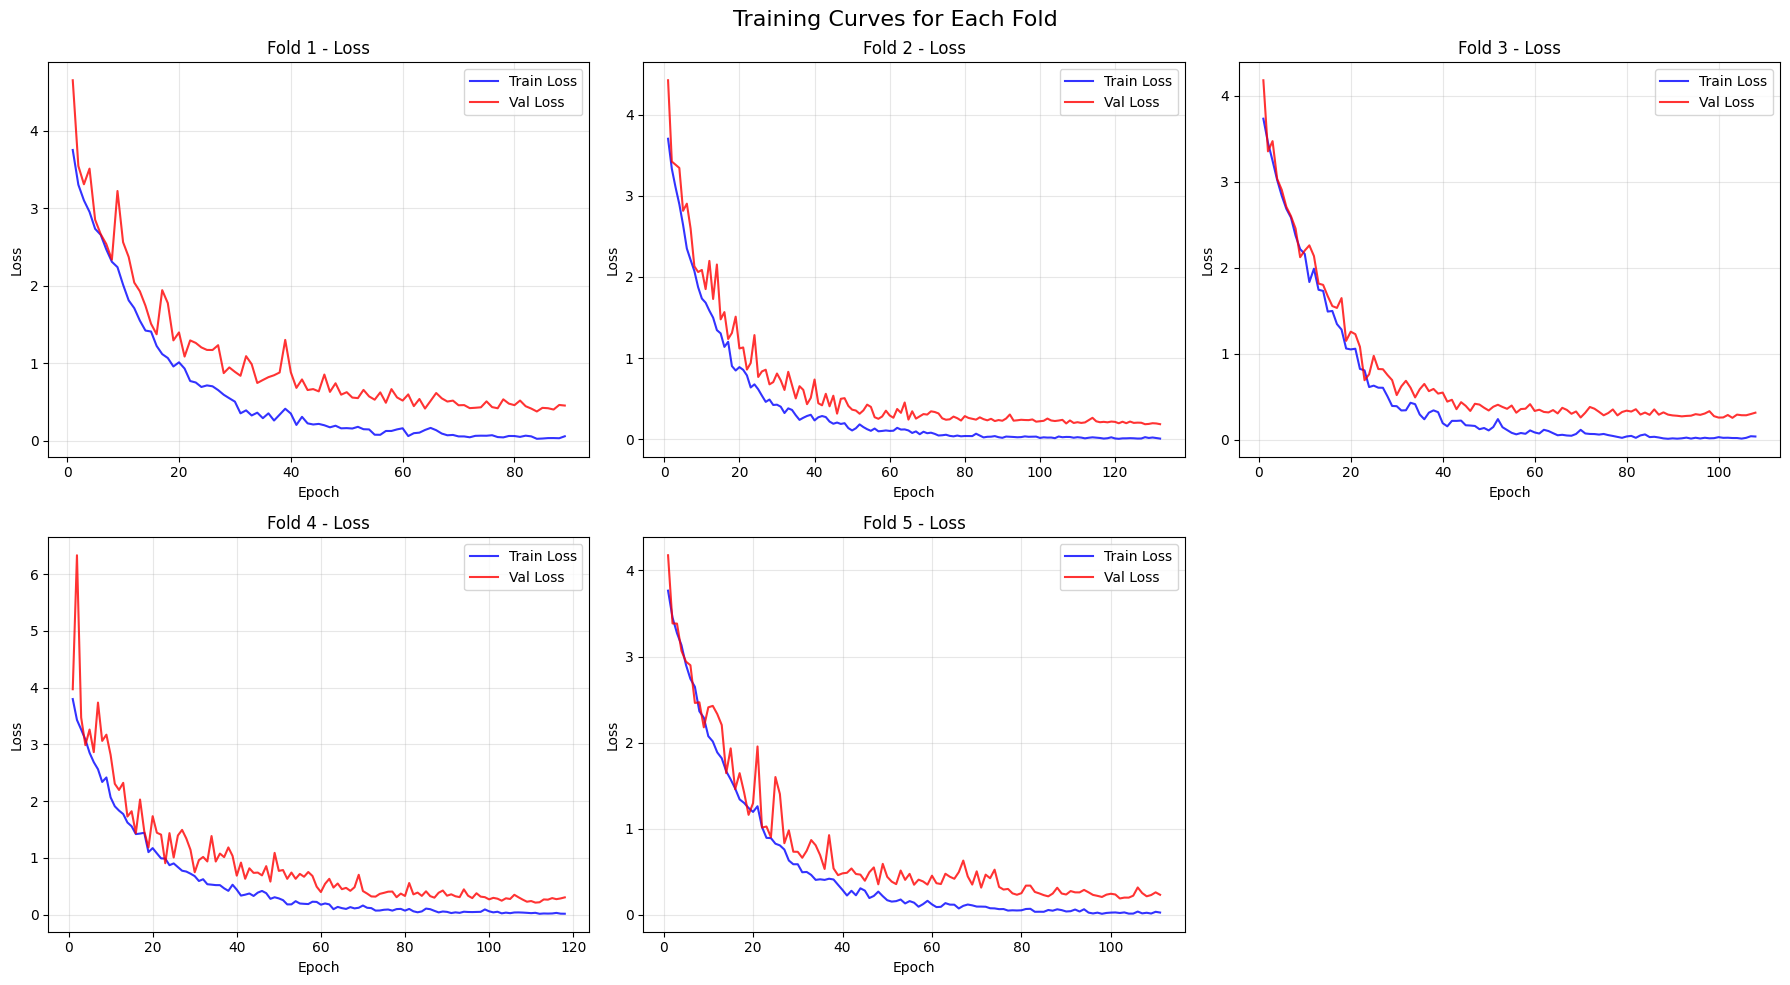

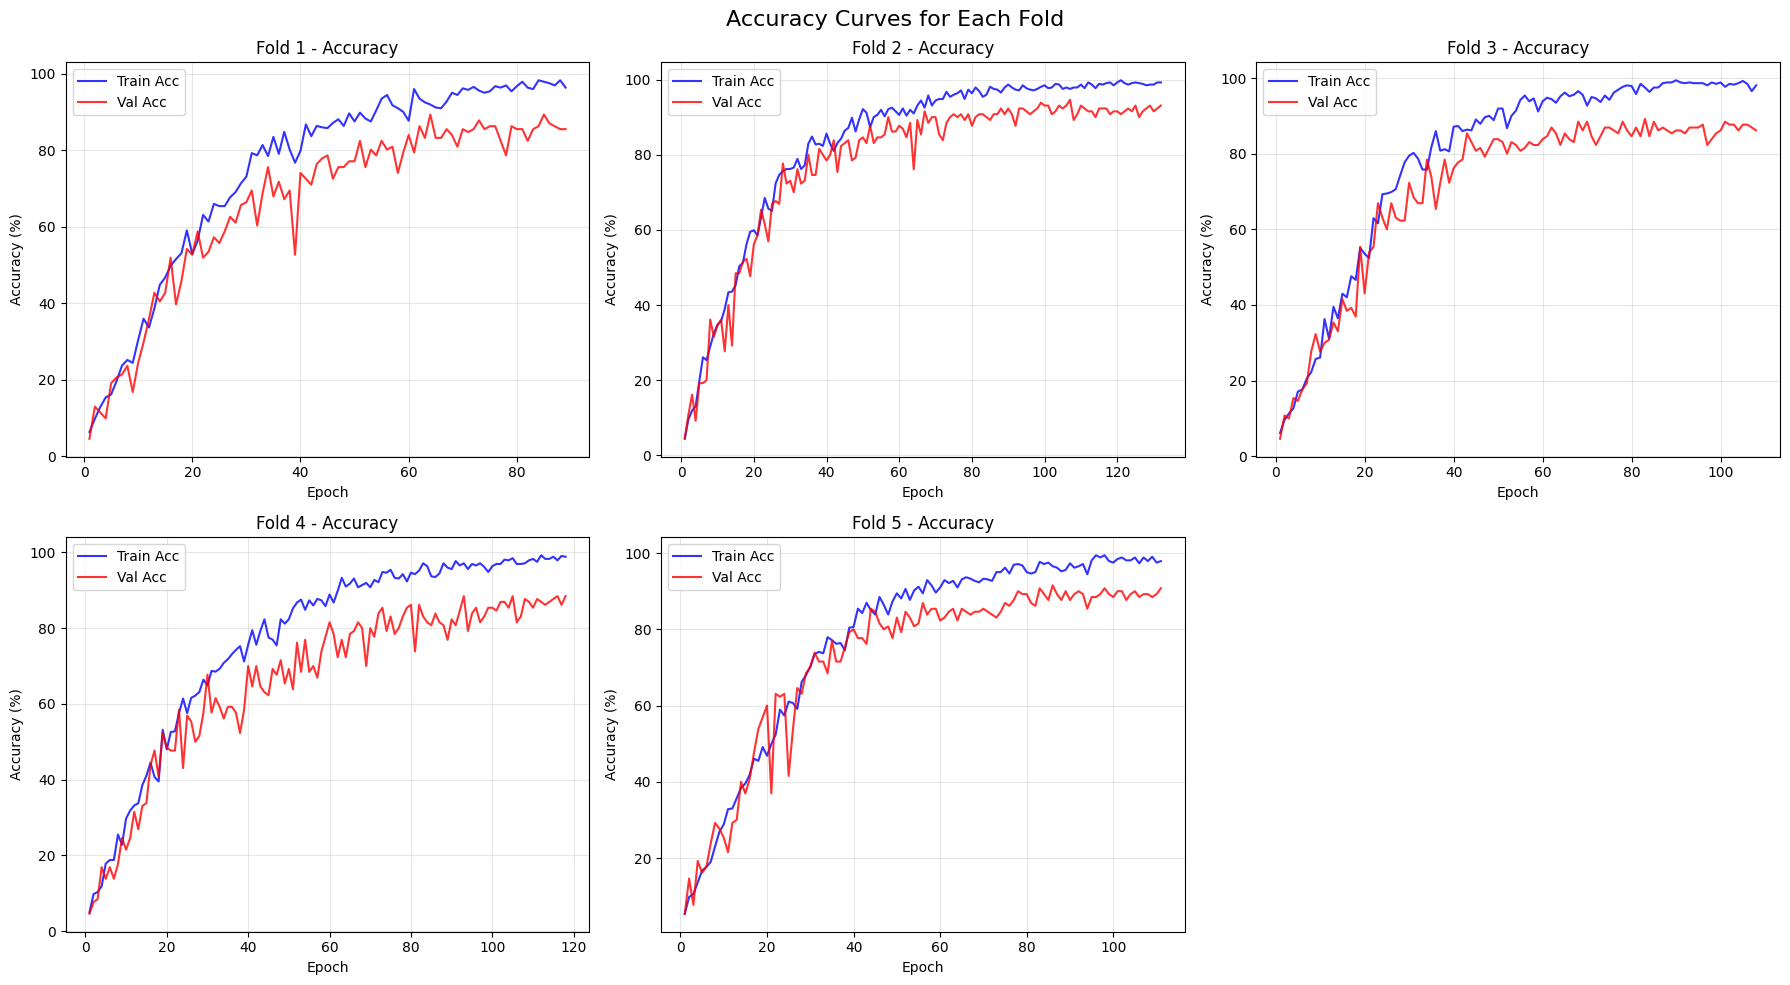

In [10]:
fig, axes = plt.subplots(2, 3, figsize=(18, 10))
fig.suptitle('Training Curves for Each Fold', fontsize=16)

# plot loss curves
for fold_idx, history in enumerate(all_histories):
    ax = axes[0, fold_idx % 3] if fold_idx < 3 else axes[1, fold_idx % 3]
    
    epochs = range(1, len(history['train_loss']) + 1)
    ax.plot(epochs, history['train_loss'], 'b-', label='Train Loss', alpha=0.8)
    ax.plot(epochs, history['val_loss'], 'r-', label='Val Loss', alpha=0.8)
    ax.set_xlabel('Epoch')
    ax.set_ylabel('Loss')
    ax.set_title(f'Fold {fold_idx + 1} - Loss')
    ax.legend()
    ax.grid(True, alpha=0.3)

if N_FOLDS == 5:
    fig.delaxes(axes[1, 2])

plt.tight_layout()
plt.savefig('efficientnet1d_loss_curves.png', dpi=150, bbox_inches='tight')
plt.show()

# plot accuracy curves
fig, axes = plt.subplots(2, 3, figsize=(18, 10))
fig.suptitle('Accuracy Curves for Each Fold', fontsize=16)

for fold_idx, history in enumerate(all_histories):
    ax = axes[0, fold_idx % 3] if fold_idx < 3 else axes[1, fold_idx % 3]
    
    epochs = range(1, len(history['train_acc']) + 1)
    ax.plot(epochs, history['train_acc'], 'b-', label='Train Acc', alpha=0.8)
    ax.plot(epochs, history['val_acc'], 'r-', label='Val Acc', alpha=0.8)
    ax.set_xlabel('Epoch')
    ax.set_ylabel('Accuracy (%)')
    ax.set_title(f'Fold {fold_idx + 1} - Accuracy')
    ax.legend()
    ax.grid(True, alpha=0.3)

if N_FOLDS == 5:
    fig.delaxes(axes[1, 2])

plt.tight_layout()
plt.savefig('efficientnet1d_accuracy_curves.png', dpi=150, bbox_inches='tight')
plt.show()

## K-Fold Results Visualization

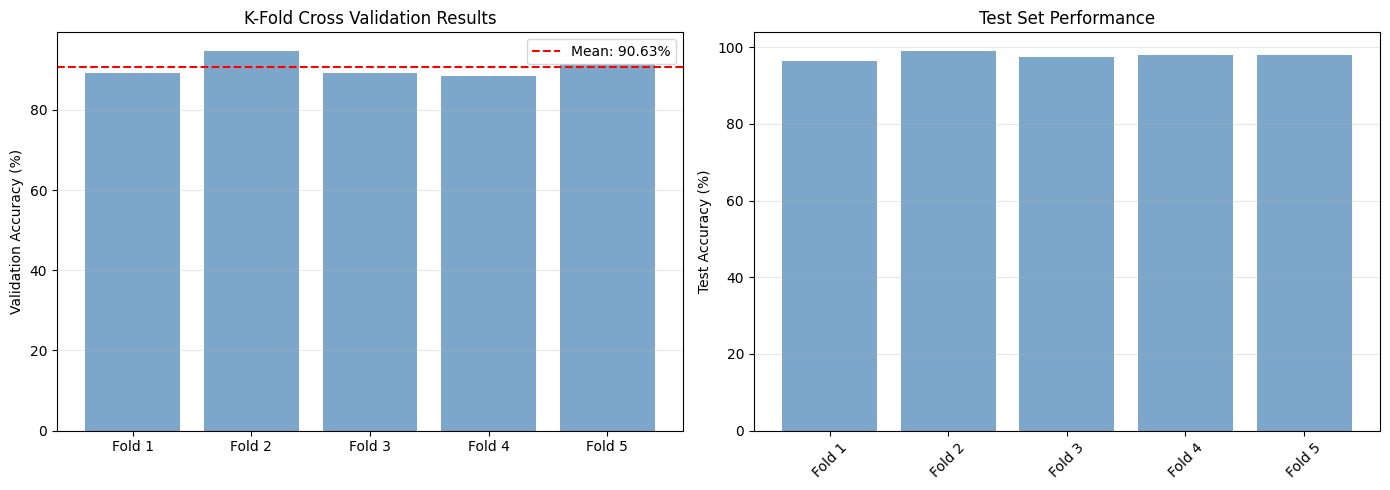


Summary Statistics:
Validation: 90.63% +/- 2.24%
Test (best fold): 98.92%


In [11]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# validation accuracies across folds
fold_nums = [f'Fold {i+1}' for i in range(N_FOLDS)]
ax1.bar(fold_nums, fold_results, color='steelblue', alpha=0.7)
ax1.axhline(y=mean_acc, color='r', linestyle='--', label=f'Mean: {mean_acc:.2f}%')
ax1.set_ylabel('Validation Accuracy (%)')
ax1.set_title('K-Fold Cross Validation Results')
ax1.legend()
ax1.grid(True, alpha=0.3, axis='y')

# test accuracies
test_labels = [f'Fold {i+1}' for i in range(N_FOLDS)]
test_values = individual_test_accs
ax2.bar(test_labels, test_values, color='steelblue', alpha=0.7)
ax2.set_ylabel('Test Accuracy (%)')
ax2.set_title('Test Set Performance')
ax2.grid(True, alpha=0.3, axis='y')
ax2.tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.savefig('efficientnet1d_kfold_results.png', dpi=150, bbox_inches='tight')
plt.show()

# summary stats
print("\nSummary Statistics:")
print(f"Validation: {mean_acc:.2f}% +/- {std_acc:.2f}%")
print(f"Test (best fold): {max(individual_test_accs):.2f}%")

## Save Final Results

In [12]:
# compile all results
final_results = {
    'model': 'EfficientNet-B0 1D',
    'configuration': {
        'batch_size': BATCH_SIZE,
        'epochs': EPOCHS,
        'learning_rate': LEARNING_RATE,
        'weight_decay': WEIGHT_DECAY,
        'focal_alpha': FOCAL_ALPHA,
        'focal_gamma': FOCAL_GAMMA,
        'patience': PATIENCE,
        'n_folds': N_FOLDS,
        'data_augmentation': {
            'noise_std': NOISE_STD,
            'scale_range': SCALE_RANGE,
            'shift_range': SHIFT_RANGE
        }
    },
    'cross_validation': {
        'fold_results': [float(x) for x in fold_results],
        'mean_val_acc': float(mean_acc),
        'std_val_acc': float(std_acc)
    },
    'test_results': {
        'individual_fold_accs': [float(x) for x in individual_test_accs],
        'best_fold': int(np.argmax(individual_test_accs) + 1),
        'best_test_acc': float(max(individual_test_accs))
    }
}

# save to json
with open('efficientnet1d_results.json', 'w') as f:
    json.dump(final_results, f, indent=2)

print("Results saved to efficientnet1d_results.json")
print("="*60)
print("FINAL RESULTS SUMMARY")
print("="*60)
print(f"Model: EfficientNet-B0 1D")
print(f"Cross-Validation Mean: {mean_acc:.2f}% +/- {std_acc:.2f}%")
print(f"Best Fold Test Accuracy: {max(individual_test_accs):.2f}%")
print("="*60)

Results saved to efficientnet1d_results.json
FINAL RESULTS SUMMARY
Model: EfficientNet-B0 1D
Cross-Validation Mean: 90.63% +/- 2.24%
Best Fold Test Accuracy: 98.92%


In [13]:

# Let me trace through the model to see what's happening
import torch
import torch.nn as nn

class Swish(nn.Module):
    def forward(self, x):
        return x * torch.sigmoid(x)

class SEBlock1D(nn.Module):
    def __init__(self, channels, reduction=16):
        super().__init__()
        self.avg_pool = nn.AdaptiveAvgPool1d(1)
        reduced_channels = max(1, channels // reduction)
        self.fc1 = nn.Linear(channels, reduced_channels)
        self.fc2 = nn.Linear(reduced_channels, channels)
        self.activation = Swish()
    
    def forward(self, x):
        batch_size, channels, _ = x.size()
        squeeze = self.avg_pool(x).view(batch_size, channels)
        excitation = self.fc1(squeeze)
        excitation = self.activation(excitation)
        excitation = self.fc2(excitation)
        excitation = torch.sigmoid(excitation)
        return x * excitation.view(batch_size, channels, 1)

class MBConvBlock1D(nn.Module):
    def __init__(self, in_channels, out_channels, kernel_size, stride, expansion_factor, se_ratio=0.25):
        super().__init__()
        self.stride = stride
        self.in_channels = in_channels
        self.out_channels = out_channels
        expanded_channels = int(in_channels * expansion_factor)

        self.activation = Swish()

        self.expand_conv = None
        self.expand_bn = None
        if expansion_factor != 1:
            self.expand_conv = nn.Conv1d(in_channels, expanded_channels, kernel_size=1, stride=1, padding=0, bias=False)
            self.expand_bn = nn.BatchNorm1d(expanded_channels)

        self.dw_conv = nn.Conv1d(expanded_channels, expanded_channels, kernel_size=kernel_size,
                                   stride=stride, padding=kernel_size//2, groups=expanded_channels, bias=False)
        self.dw_bn = nn.BatchNorm1d(expanded_channels)
        self.se = SEBlock1D(expanded_channels, reduction=16)

        self.project_conv = nn.Conv1d(expanded_channels, out_channels, kernel_size=1, stride=1, padding=0, bias=False)
        self.project_bn = nn.BatchNorm1d(out_channels)

        self.use_skip = (stride == 1 and in_channels == out_channels)

    def forward(self, x):
        if self.expand_conv:
            out = self.expand_conv(x)
            out = self.expand_bn(out)
            out = self.activation(out)
        else:
            out = x

        out = self.dw_conv(out)
        out = self.dw_bn(out)
        out = self.activation(out)
        out = self.se(out)

        out = self.project_conv(out)
        out = self.project_bn(out)

        if self.use_skip:
            out = out + x

        return out

# Test the blocks one by one
block_configs = [
    (32, 16, 3, 1, 1, 1),      # MBConv1
    (16, 24, 3, 2, 6, 1),      # MBConv6, stride 2
    (24, 24, 3, 1, 6, 1),      # MBConv6, stride 1
    (24, 40, 5, 2, 6, 1),      # MBConv6, stride 2
    (40, 40, 5, 1, 6, 1),      # MBConv6, stride 1
    (40, 80, 3, 2, 6, 1),      # MBConv6, stride 2
    (80, 80, 3, 1, 6, 2),      # MBConv6, stride 1 (x2)
    (80, 112, 5, 1, 6, 3),     # MBConv6, stride 1 (x3)
    (112, 192, 5, 2, 6, 1),    # MBConv6, stride 2
    (192, 192, 5, 1, 6, 3),    # MBConv6, stride 1 (x3)
    (192, 320, 3, 1, 6, 1),    # MBConv6, stride 1
]

# Trace through
x = torch.randn(1, 32, 1738)  # After stem (stride 2)
print(f"After stem: {x.shape}")

block_idx = 0
for in_c, out_c, k, s, e, repeats in block_configs:
    for i in range(repeats):
        print(f"\nBlock {block_idx}: in={in_c}, out={out_c}, k={k}, s={s}, e={e}")
        print(f"  Input shape: {x.shape}")
        block = MBConvBlock1D(in_c, out_c, k, s, e)
        x = block(x)
        print(f"  Output shape: {x.shape}")
        block_idx += 1


After stem: torch.Size([1, 32, 1738])

Block 0: in=32, out=16, k=3, s=1, e=1
  Input shape: torch.Size([1, 32, 1738])
  Output shape: torch.Size([1, 16, 1738])

Block 1: in=16, out=24, k=3, s=2, e=6
  Input shape: torch.Size([1, 16, 1738])
  Output shape: torch.Size([1, 24, 869])

Block 2: in=24, out=24, k=3, s=1, e=6
  Input shape: torch.Size([1, 24, 869])
  Output shape: torch.Size([1, 24, 869])

Block 3: in=24, out=40, k=5, s=2, e=6
  Input shape: torch.Size([1, 24, 869])
  Output shape: torch.Size([1, 40, 435])

Block 4: in=40, out=40, k=5, s=1, e=6
  Input shape: torch.Size([1, 40, 435])
  Output shape: torch.Size([1, 40, 435])

Block 5: in=40, out=80, k=3, s=2, e=6
  Input shape: torch.Size([1, 40, 435])
  Output shape: torch.Size([1, 80, 218])

Block 6: in=80, out=80, k=3, s=1, e=6
  Input shape: torch.Size([1, 80, 218])
  Output shape: torch.Size([1, 80, 218])

Block 7: in=80, out=80, k=3, s=1, e=6
  Input shape: torch.Size([1, 80, 218])
  Output shape: torch.Size([1, 80, 218])

RuntimeError: Given groups=1, weight of size [480, 80, 1], expected input[1, 112, 218] to have 80 channels, but got 112 channels instead

In [ ]:

# The correct block config - each block needs proper chaining
# When you have multiple repeats of same (in, out), the FIRST one does the transformation
# Then subsequent ones all have in=out with stride=1

block_configs_fixed = [
    (32, 16, 3, 1, 1, 1),      # Block 0
    (16, 24, 3, 2, 6, 1),      # Block 1: stride 2
    (24, 24, 3, 1, 6, 1),      # Block 2: stride 1
    (24, 40, 5, 2, 6, 1),      # Block 3: stride 2
    (40, 40, 5, 1, 6, 1),      # Block 4: stride 1
    (40, 80, 3, 2, 6, 1),      # Block 5: stride 2
    (80, 80, 3, 1, 6, 2),      # Blocks 6-7: stride 1 (x2)
    (80, 112, 5, 1, 6, 3),     # Blocks 8-10: stride 1 (x3) - THIS WAS WRONG
    (112, 192, 5, 2, 6, 1),    # Block 11: stride 2
    (192, 192, 5, 1, 6, 3),    # Blocks 12-14: stride 1 (x3)
    (192, 320, 3, 1, 6, 1),    # Block 15: stride 1
]

# Test again
x = torch.randn(1, 32, 1738)
print(f"After stem: {x.shape}")

block_idx = 0
for in_c, out_c, k, s, e, repeats in block_configs_fixed:
    for i in range(repeats):
        print(f"Block {block_idx}: in={in_c}, out={out_c}, k={k}, s={s}, e={e}, input_shape={x.shape}")
        block = MBConvBlock1D(in_c, out_c, k, s, e)
        x = block(x)
        print(f"  -> output_shape={x.shape}")
        block_idx += 1

print(f"\nFinal shape before head: {x.shape}")
print("Success!")


After stem: torch.Size([1, 32, 1738])
Block 0: in=32, out=16, k=3, s=1, e=1, input_shape=torch.Size([1, 32, 1738])
  -> output_shape=torch.Size([1, 16, 1738])
Block 1: in=16, out=24, k=3, s=2, e=6, input_shape=torch.Size([1, 16, 1738])
  -> output_shape=torch.Size([1, 24, 869])
Block 2: in=24, out=24, k=3, s=1, e=6, input_shape=torch.Size([1, 24, 869])
  -> output_shape=torch.Size([1, 24, 869])
Block 3: in=24, out=40, k=5, s=2, e=6, input_shape=torch.Size([1, 24, 869])
  -> output_shape=torch.Size([1, 40, 435])
Block 4: in=40, out=40, k=5, s=1, e=6, input_shape=torch.Size([1, 40, 435])
  -> output_shape=torch.Size([1, 40, 435])
Block 5: in=40, out=80, k=3, s=2, e=6, input_shape=torch.Size([1, 40, 435])
  -> output_shape=torch.Size([1, 80, 218])
Block 6: in=80, out=80, k=3, s=1, e=6, input_shape=torch.Size([1, 80, 218])
  -> output_shape=torch.Size([1, 80, 218])
Block 7: in=80, out=80, k=3, s=1, e=6, input_shape=torch.Size([1, 80, 218])
  -> output_shape=torch.Size([1, 80, 218])
Block 8

RuntimeError: Given groups=1, weight of size [480, 80, 1], expected input[1, 112, 218] to have 80 channels, but got 112 channels instead

In [ ]:

# The REAL fix - when repeats > 1, subsequent blocks need matching in channels
block_configs_correct = [
    (32, 16, 3, 1, 1, 1),      # Block 0
    (16, 24, 3, 2, 6, 1),      # Block 1: stride 2
    (24, 24, 3, 1, 6, 1),      # Block 2: stride 1
    (24, 40, 5, 2, 6, 1),      # Block 3: stride 2
    (40, 40, 5, 1, 6, 1),      # Block 4: stride 1
    (40, 80, 3, 2, 6, 1),      # Block 5: stride 2
    (80, 80, 3, 1, 6, 2),      # Blocks 6-7: stride 1 (x2)
    (80, 112, 5, 1, 6, 1),     # Block 8
    (112, 112, 5, 1, 6, 2),    # Blocks 9-10: stride 1 (x2) - FIX: input=112 not 80
    (112, 192, 5, 2, 6, 1),    # Block 11: stride 2
    (192, 192, 5, 1, 6, 3),    # Blocks 12-14: stride 1 (x3)
    (192, 320, 3, 1, 6, 1),    # Block 15: stride 1
]

# Test again
x = torch.randn(1, 32, 1738)
print(f"After stem: {x.shape}\n")

block_idx = 0
for in_c, out_c, k, s, e, repeats in block_configs_correct:
    for i in range(repeats):
        print(f"Block {block_idx}: in={in_c}, out={out_c}, k={k}, s={s}, e={e} | input={x.shape}")
        block = MBConvBlock1D(in_c, out_c, k, s, e)
        x = block(x)
        print(f"  -> output={x.shape}")
        block_idx += 1

print(f"\nFinal shape before head: {x.shape}")
print("✓ Success!")


After stem: torch.Size([1, 32, 1738])

Block 0: in=32, out=16, k=3, s=1, e=1 | input=torch.Size([1, 32, 1738])
  -> output=torch.Size([1, 16, 1738])
Block 1: in=16, out=24, k=3, s=2, e=6 | input=torch.Size([1, 16, 1738])
  -> output=torch.Size([1, 24, 869])
Block 2: in=24, out=24, k=3, s=1, e=6 | input=torch.Size([1, 24, 869])
  -> output=torch.Size([1, 24, 869])
Block 3: in=24, out=40, k=5, s=2, e=6 | input=torch.Size([1, 24, 869])
  -> output=torch.Size([1, 40, 435])
Block 4: in=40, out=40, k=5, s=1, e=6 | input=torch.Size([1, 40, 435])
  -> output=torch.Size([1, 40, 435])
Block 5: in=40, out=80, k=3, s=2, e=6 | input=torch.Size([1, 40, 435])
  -> output=torch.Size([1, 80, 218])
Block 6: in=80, out=80, k=3, s=1, e=6 | input=torch.Size([1, 80, 218])
  -> output=torch.Size([1, 80, 218])
Block 7: in=80, out=80, k=3, s=1, e=6 | input=torch.Size([1, 80, 218])
  -> output=torch.Size([1, 80, 218])
Block 8: in=80, out=112, k=5, s=1, e=6 | input=torch.Size([1, 80, 218])
  -> output=torch.Size